# 10. Qwen3.5-2B Full Retraining

## 1. Purpose of this notebook

This notebook creates the **Full Retraining reference models** for the five kidney-transplant deletion requests.

For each deletion scenario, the relevant training records are removed and a **fresh Qwen3.5-2B-Base classifier** is trained using the retained training data only. The final trained Qwen baseline is used only to recover the frozen experimental settings; it is **not** used to initialise Full Retraining.

The resulting models provide the reference behaviour that later approximate unlearning methods, such as Gradient Difference, can be compared against.

The notebook keeps the same dataset, permanent data split, 18 classifier features, deletion memberships, text serialisation, threshold and Qwen training configuration used in the existing experiment.

### 1.1 What this notebook produces

For each of the five deletion scenarios, the notebook saves:

- the best Full Retraining adapter and classification head;
- the epoch-by-epoch training history;
- retained-test utility metrics;
- retained-test probabilities;
- forget-set probabilities for later unlearning comparison; and
- runtime and GPU-memory information.

Two figures are produced after training:

1. validation PR-AUC across epochs; and
2. retained-test PR-AUC across the five Full Retraining models, with the Original Qwen result shown when it can be recovered from the saved baseline outputs.

## 2. Setup

### 2.1 Import general libraries

In [1]:
from pathlib import Path
import gc
import json
import os
import random
import shutil
import time
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from IPython.display import display
from tqdm.auto import tqdm

### 2.2 Import Qwen and evaluation libraries

In [2]:
# Unsloth is imported before Transformers so that its model patches are applied.
import unsloth
from unsloth import FastVisionModel

from peft import PeftModel
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

print("Qwen and evaluation imports: OK")

/usr/local/lib/python3.12/dist-packages/unsloth/_gpu_init.py:98: UserWarning: Unsloth: torchaudio cannot initialise against this torch and has been disabled for this process, so anything that needs it will report it as missing rather than crash at import. Install the matching wheel to restore it. Original error: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchaudio/lib/libtorchaudio.so
  disable_torchaudio_if_cuda_mismatched()


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Qwen and evaluation imports: OK


### 2.3 Check the RunPod environment

In [3]:
REPO_ROOT = Path("/workspace/qub-machine-unlearning")
QWEN_ROOT = Path("/workspace/qwen35_classifier_runpod")

if not REPO_ROOT.exists():
    raise FileNotFoundError(f"Repository not found: {REPO_ROOT}")

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is unavailable. Reconnect this notebook to the RunPod GPU kernel before continuing."
    )

DEVICE = torch.device("cuda")

print("Repository:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))

Repository: /workspace/qub-machine-unlearning
PyTorch: 2.11.0+cu130
GPU: NVIDIA A100-SXM4-80GB


### 2.4 Reproducibility

In [4]:
SEED = 42

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

print("Random seed:", SEED)

Random seed: 42


### 2.5 Create a new output folder

In [5]:
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

RUN_ROOT = QWEN_ROOT / "full_retraining" / RUN_ID
MODEL_ROOT = RUN_ROOT / "models"
RESULT_ROOT = RUN_ROOT / "results"
FIGURE_ROOT = RUN_ROOT / "figures"

MODEL_ROOT.mkdir(parents=True, exist_ok=True)
RESULT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

print("Run ID:", RUN_ID)
print("Output folder:", RUN_ROOT)

Run ID: 20260830T134352Z
Output folder: /workspace/qwen35_classifier_runpod/full_retraining/20260830T134352Z


## 3. Load the frozen experiment inputs

### 3.1 Locate the final-submission folder

The repository has previously been stored with `final_submission` inside the `code` folder on RunPod. The small search below also supports the older locations so the notebook does not depend on the current working directory.

In [6]:
def locate_submission_root(repo_root):
    candidates = [
        repo_root / "code" / "final_submission",
        repo_root / "final_submission",
        repo_root,
    ]

    for candidate in candidates:
        dataset = candidate / "data" / "final" / "kidney_transplant_assessments.csv"
        if dataset.is_file():
            return candidate

    raise FileNotFoundError("Could not locate the final submission dataset.")

ROOT = locate_submission_root(REPO_ROOT)

print("Final-submission root:", ROOT)

Final-submission root: /workspace/qub-machine-unlearning/code/final_submission


### 3.2 Define the frozen input paths

In [7]:
DATA_DIR = ROOT / "data" / "final"
PROCESSED_DIR = ROOT / "processed_data"

ASSESSMENT_PATH = DATA_DIR / "kidney_transplant_assessments.csv"
FEATURE_PATH = DATA_DIR / "classifier_feature_list.json"
DELETION_AUDIT_PATH = DATA_DIR / "deletion_scenario_audit.csv"
SPLIT_PATH = PROCESSED_DIR / "split_assignments.csv"
MEMBERSHIP_PATH = PROCESSED_DIR / "deletion_scenario_membership.csv"

input_paths = {
    "Assessments": ASSESSMENT_PATH,
    "Feature contract": FEATURE_PATH,
    "Deletion audit": DELETION_AUDIT_PATH,
    "Split assignments": SPLIT_PATH,
    "Deletion membership": MEMBERSHIP_PATH,
}

missing = [str(path) for path in input_paths.values() if not path.is_file()]

if missing:
    raise FileNotFoundError("Missing frozen input(s): " + "; ".join(missing))

display(
    pd.DataFrame(
        [{"Input": name, "Path": str(path)} for name, path in input_paths.items()]
    )
)

,Input,Path
0,Assessments,/workspace/qub-machine-unlearning/code/final_s...
1,Feature contract,/workspace/qub-machine-unlearning/code/final_s...
2,Deletion audit,/workspace/qub-machine-unlearning/code/final_s...
3,Split assignments,/workspace/qub-machine-unlearning/code/final_s...
4,Deletion membership,/workspace/qub-machine-unlearning/code/final_s...


## 4. Load the final Qwen baseline settings

### 4.1 Select the final baseline run

The final baseline run is the saved **1e-5 Qwen run**. Its trained weights are not used for Full Retraining. Only its saved experiment configuration, threshold and serialisation specification are loaded.

In [8]:
BASELINE_RUN_ID = "20260829T151430Z"

BASELINE_RESULT_DIR = QWEN_ROOT / "results" / BASELINE_RUN_ID
BASELINE_CONFIG_PATH = BASELINE_RESULT_DIR / "experiment_configuration.json"
BASELINE_THRESHOLD_PATH = BASELINE_RESULT_DIR / "selected_threshold.json"
BASELINE_SERIALISATION_PATH = BASELINE_RESULT_DIR / "serialisation_specification.json"

required_baseline_files = [
    BASELINE_CONFIG_PATH,
    BASELINE_THRESHOLD_PATH,
    BASELINE_SERIALISATION_PATH,
]

missing = [str(path) for path in required_baseline_files if not path.is_file()]

if missing:
    raise FileNotFoundError(
        "The final Qwen baseline files could not be found: " + "; ".join(missing)
    )

print("Baseline run:", BASELINE_RUN_ID)

Baseline run: 20260829T151430Z


### 4.2 Load the saved configuration

In [9]:
baseline_config = json.loads(
    BASELINE_CONFIG_PATH.read_text(encoding="utf-8")
)
baseline_threshold = json.loads(
    BASELINE_THRESHOLD_PATH.read_text(encoding="utf-8")
)
baseline_serialisation = json.loads(
    BASELINE_SERIALISATION_PATH.read_text(encoding="utf-8")
)

MODEL_ID = baseline_config["model_id"]
FROZEN_THRESHOLD = float(baseline_threshold["threshold"])

print("Model:", MODEL_ID)
print("Frozen classification threshold:", FROZEN_THRESHOLD)

Model: unsloth/Qwen3.5-2B-Base
Frozen classification threshold: 0.55


### 4.3 Show the training settings that will be reused

In [10]:
training_config = baseline_config["training"]

MAX_SEQ_LENGTH = int(baseline_config["max_seq_length"])
BATCH_SIZE = int(training_config["batch size"])
EFFECTIVE_BATCH_SIZE = int(training_config["effective batch size"])
GRADIENT_ACCUMULATION_STEPS = EFFECTIVE_BATCH_SIZE // BATCH_SIZE

LEARNING_RATE = float(training_config["learning rate"])
MAX_EPOCHS = int(training_config["maximum epochs"])
WEIGHT_DECAY = float(training_config["weight decay"])
EARLY_STOPPING_PATIENCE = int(training_config["early stopping patience"])

LORA_RANK = int(training_config["LoRA rank"])
LORA_ALPHA = int(training_config["LoRA alpha"])
LORA_DROPOUT = float(training_config["LoRA dropout"])

GRADIENT_CLIP_NORM = 1.0

training_settings = pd.DataFrame(
    [
        ["Model", MODEL_ID],
        ["Batch size", BATCH_SIZE],
        ["Gradient accumulation", GRADIENT_ACCUMULATION_STEPS],
        ["Effective batch size", EFFECTIVE_BATCH_SIZE],
        ["Learning rate", LEARNING_RATE],
        ["Maximum epochs", MAX_EPOCHS],
        ["Weight decay", WEIGHT_DECAY],
        ["Early stopping patience", EARLY_STOPPING_PATIENCE],
        ["LoRA rank", LORA_RANK],
        ["LoRA alpha", LORA_ALPHA],
        ["LoRA dropout", LORA_DROPOUT],
        ["LoRA targets", "all-linear"],
        ["Maximum sequence length", MAX_SEQ_LENGTH],
        ["Frozen threshold", FROZEN_THRESHOLD],
    ],
    columns=["Setting", "Value"],
)

display(training_settings)

,Setting,Value
0,Model,unsloth/Qwen3.5-2B-Base
1,Batch size,8
2,Gradient accumulation,4
3,Effective batch size,32
4,Learning rate,0.00001
5,Maximum epochs,10
6,Weight decay,0.01
7,Early stopping patience,2
8,LoRA rank,16
9,LoRA alpha,16


### 4.4 Check the important frozen settings

In [11]:
assert MODEL_ID == "unsloth/Qwen3.5-2B-Base"
assert LEARNING_RATE == 1e-5
assert BATCH_SIZE == 8
assert GRADIENT_ACCUMULATION_STEPS == 4
assert LORA_RANK == 16
assert LORA_ALPHA == 16
assert LORA_DROPOUT == 0

print("Frozen Qwen training contract: PASS")

Frozen Qwen training contract: PASS


## 5. Load the dataset and permanent split

### 5.1 Load the assessments and feature contract

In [12]:
assessments = pd.read_csv(ASSESSMENT_PATH)

feature_contract = json.loads(
    FEATURE_PATH.read_text(encoding="utf-8")
)

TARGET = feature_contract["target"]
FEATURES = feature_contract["classifier_features"]

print("Assessments:", len(assessments))
print("Target:", TARGET)
print("Classifier features:", len(FEATURES))

Assessments: 60000
Target: acute_rejection_within_30_days
Classifier features: 18


### 5.2 Check the 18 classifier features

In [13]:
EXPECTED_FEATURES = [
    "recipient_age",
    "donor_age",
    "donor_type",
    "kidney_failure_cause",
    "previous_transplant",
    "dialysis_months",
    "abo_compatibility_category",
    "hla_mismatch_count",
    "antibody_risk_score",
    "cold_ischaemia_hours",
    "days_since_transplant",
    "creatinine_mg_dl",
    "creatinine_change_pct",
    "urine_output_ml_24h",
    "tacrolimus_level_ng_ml",
    "medication_adherence_pct",
    "infection_indicator",
    "previous_rejection",
]

BLOCKED_COLUMNS = {
    "assessment_id",
    "recipient_id",
    "donor_id",
    "hospital_id",
    "assessment_date",
    "training_consent_status",
    "training_consent_version",
    "retention_expiry_date",
    TARGET,
}

assert len(assessments) == 60_000
assert TARGET == "acute_rejection_within_30_days"
assert FEATURES == EXPECTED_FEATURES
assert set(FEATURES).isdisjoint(BLOCKED_COLUMNS)

feature_table = pd.DataFrame(
    {
        "Number": range(1, len(FEATURES) + 1),
        "Classifier feature": FEATURES,
    }
)

display(feature_table)

,Number,Classifier feature
0,1,recipient_age
1,2,donor_age
2,3,donor_type
3,4,kidney_failure_cause
4,5,previous_transplant
5,6,dialysis_months
6,7,abo_compatibility_category
7,8,hla_mismatch_count
8,9,antibody_risk_score
9,10,cold_ischaemia_hours


### 5.3 Load the permanent train, validation and test split

In [14]:
split_assignments = pd.read_csv(SPLIT_PATH)

assert split_assignments["recipient_id"].is_unique

data = assessments.merge(
    split_assignments[["recipient_id", "donor_id", "split"]],
    on=["recipient_id", "donor_id"],
    how="left",
    validate="many_to_one",
)

assert data["split"].notna().all()

split_frames = {
    split_name: data.loc[data["split"].eq(split_name)].copy().reset_index(drop=True)
    for split_name in ["train", "validation", "test"]
}

for frame in split_frames.values():
    frame["label"] = frame[TARGET].astype("int64")

### 5.4 Check split sizes and target prevalence

In [15]:
split_summary = pd.DataFrame(
    [
        {
            "Split": split_name,
            "Rows": len(frame),
            "Positive cases": int(frame[TARGET].sum()),
            "Positive prevalence": frame[TARGET].mean(),
        }
        for split_name, frame in split_frames.items()
    ]
)

display(split_summary)

assert len(split_frames["train"]) == 42_024
assert len(split_frames["validation"]) == 8_988
assert len(split_frames["test"]) == 8_988

print("Permanent split: PASS")

,Split,Rows,Positive cases,Positive prevalence
0,train,42024,3160,0.075195
1,validation,8988,669,0.074433
2,test,8988,665,0.073988


Permanent split: PASS


## 6. Reuse the five deletion scenarios

### 6.1 Define the scenario order and expected training forget sizes

In [16]:
SCENARIOS = [
    "recipient_withdrawal",
    "donor_withdrawal",
    "hospital_removal",
    "invalid_consent",
    "retention_expiry",
]

SCENARIO_LABELS = {
    "recipient_withdrawal": "Recipient Withdrawal",
    "donor_withdrawal": "Donor Withdrawal",
    "hospital_removal": "Hospital Removal",
    "invalid_consent": "Invalid Consent",
    "retention_expiry": "Retention Expiry",
}

EXPECTED_TRAINING_FORGET_COUNTS = {
    "recipient_withdrawal": 426,
    "donor_withdrawal": 1_992,
    "hospital_removal": 4_314,
    "invalid_consent": 4_148,
    "retention_expiry": 6_262,
}

display(
    pd.DataFrame(
        [
            {
                "Scenario": SCENARIO_LABELS[scenario],
                "Expected training forget rows": EXPECTED_TRAINING_FORGET_COUNTS[scenario],
            }
            for scenario in SCENARIOS
        ]
    )
)

,Scenario,Expected training forget rows
0,Recipient Withdrawal,426
1,Donor Withdrawal,1992
2,Hospital Removal,4314
3,Invalid Consent,4148
4,Retention Expiry,6262


### 6.2 Load the saved membership file

In [17]:
membership = pd.read_csv(MEMBERSHIP_PATH)
deletion_audit = pd.read_csv(DELETION_AUDIT_PATH).set_index("scenario")

assert set(membership["scenario"]) == set(SCENARIOS)
assert not membership.duplicated(["scenario", "assessment_id"]).any()
assert list(deletion_audit.index) == SCENARIOS

print("Saved deletion membership loaded.")

Saved deletion membership loaded.


### 6.3 Build one forget/retain split per scenario

In [18]:
scenario_sets = {}

for scenario in SCENARIOS:
    scenario_membership = membership.loc[
        membership["scenario"].eq(scenario)
    ]

    forget_ids = set(
        scenario_membership.loc[
            scenario_membership["membership_type"].eq("training_forget"),
            "assessment_id",
        ]
    )

    deleted_validation_ids = set(
        scenario_membership.loc[
            scenario_membership["membership_type"].eq("deleted_validation"),
            "assessment_id",
        ]
    )

    deleted_test_ids = set(
        scenario_membership.loc[
            scenario_membership["membership_type"].eq("deleted_test"),
            "assessment_id",
        ]
    )

    training_forget = split_frames["train"].loc[
        split_frames["train"]["assessment_id"].isin(forget_ids)
    ].copy()

    retained_train = split_frames["train"].loc[
        ~split_frames["train"]["assessment_id"].isin(forget_ids)
    ].copy()

    retained_validation = split_frames["validation"].loc[
        ~split_frames["validation"]["assessment_id"].isin(deleted_validation_ids)
    ].copy()

    retained_test = split_frames["test"].loc[
        ~split_frames["test"]["assessment_id"].isin(deleted_test_ids)
    ].copy()

    scenario_sets[scenario] = {
        "training_forget": training_forget,
        "retained_train": retained_train,
        "retained_validation": retained_validation,
        "retained_test": retained_test,
    }

### 6.4 Show the resulting scenario sizes

In [19]:
scenario_size_table = pd.DataFrame(
    [
        {
            "Scenario": SCENARIO_LABELS[scenario],
            "Training forget": len(parts["training_forget"]),
            "Retained training": len(parts["retained_train"]),
            "Retained validation": len(parts["retained_validation"]),
            "Retained test": len(parts["retained_test"]),
            "Training removed (%)": (
                100 * len(parts["training_forget"]) / len(split_frames["train"])
            ),
        }
        for scenario, parts in scenario_sets.items()
    ]
)

display(scenario_size_table)

,Scenario,Training forget,Retained training,Retained validation,Retained test,Training removed (%)
0,Recipient Withdrawal,426,41598,8904,8898,1.013706
1,Donor Withdrawal,1992,40032,8472,8496,4.740148
2,Hospital Removal,4314,37710,8166,8124,10.265563
3,Invalid Consent,4148,37876,8046,8078,9.870550
4,Retention Expiry,6262,35762,7624,7614,14.901009


### 6.5 Verify that each scenario is internally valid

In [20]:
scenario_checks = []

for scenario, parts in scenario_sets.items():
    forget_ids = set(parts["training_forget"]["assessment_id"])
    retain_ids = set(parts["retained_train"]["assessment_id"])

    checks = {
        "Expected forget count": (
            len(parts["training_forget"])
            == EXPECTED_TRAINING_FORGET_COUNTS[scenario]
        ),
        "Forget + retain = original training": (
            len(parts["training_forget"]) + len(parts["retained_train"])
            == len(split_frames["train"])
        ),
        "No forget/retain overlap": forget_ids.isdisjoint(retain_ids),
    }

    scenario_checks.append(
        {
            "Scenario": SCENARIO_LABELS[scenario],
            **{name: "PASS" if passed else "FAIL" for name, passed in checks.items()},
        }
    )

    assert all(checks.values())

display(pd.DataFrame(scenario_checks))

print("Deletion scenario verification: PASS")

,Scenario,Expected forget count,Forget + retain = original training,No forget/retain overlap
0,Recipient Withdrawal,PASS,PASS,PASS
1,Donor Withdrawal,PASS,PASS,PASS
2,Hospital Removal,PASS,PASS,PASS
3,Invalid Consent,PASS,PASS,PASS
4,Retention Expiry,PASS,PASS,PASS


Deletion scenario verification: PASS


## 7. Prepare the Qwen text inputs

### 7.1 Use the same serialisation specification as the baseline

The classifier receives the same 18 model features in the same order as the baseline experiment. Identifiers, the target and deletion information are not included in the text.

In [21]:
FEATURE_LABELS = baseline_serialisation["display_labels"]

BINARY_FEATURES = {
    "previous_transplant",
    "infection_indicator",
    "previous_rejection",
}

SERIALISATION_VERSION = baseline_config["serialisation_version"]

assert baseline_serialisation["feature_order"] == FEATURES
assert baseline_serialisation["target_included"] is False
assert baseline_serialisation["identifiers_included"] is False

print("Serialisation version:", SERIALISATION_VERSION)

Serialisation version: kidney-qwen35-v1


### 7.2 Format individual feature values

In [22]:
def format_feature_value(feature, value):
    if pd.isna(value):
        return "missing"

    if feature in BINARY_FEATURES:
        return "yes" if int(value) == 1 else "no"

    if isinstance(value, (float, np.floating)):
        return f"{float(value):.4f}".rstrip("0").rstrip(".")

    return str(value).strip()

### 7.3 Convert one assessment into plain text

In [23]:
def serialize_assessment(row):
    lines = []

    for feature in FEATURES:
        label = FEATURE_LABELS[feature]
        value = format_feature_value(feature, row[feature])
        lines.append(f"{label}: {value}.")

    return "\n".join(lines)

### 7.4 Create the text once and attach it to every scenario

In [24]:
text_by_id = (
    data.assign(text=data.apply(serialize_assessment, axis=1))
    .set_index("assessment_id")["text"]
)

for parts in scenario_sets.values():
    for frame in parts.values():
        frame["text"] = frame["assessment_id"].map(text_by_id)
        frame["label"] = frame[TARGET].astype("int64")

        assert frame["text"].notna().all()

print("All scenario rows have Qwen text inputs.")

All scenario rows have Qwen text inputs.


### 7.5 Inspect one example

In [25]:
example = scenario_sets["recipient_withdrawal"]["retained_train"].iloc[0]

print(example["text"])
print()
print("Target label:", int(example["label"]))

Recipient age (years): 59.
Donor age (years): 46.
Donor type: Deceased.
Kidney failure cause: Polycystic kidney disease.
Previous transplant: no.
Dialysis duration (months): 4.
ABO compatibility: Managed incompatibility.
HLA mismatch count: 5.
Antibody risk score: 0.884.
Cold ischaemia time (hours): 4.62.
Days since transplant: 7.
Creatinine (mg/dL): 1.24.
Creatinine change (percent): -3.6519.
Urine output (mL/24h): 2450.6.
Tacrolimus level (ng/mL): 9.88.
Medication adherence (percent): 86.3.
Infection indicator: no.
Previous rejection: no.

Target label: 1


## 8. Dataset, batching and evaluation helpers

### 8.1 PyTorch dataset

In [26]:
class AssessmentTextDataset(Dataset):
    def __init__(self, frame):
        self.texts = frame["text"].tolist()
        self.labels = frame["label"].astype(int).tolist()
        self.ids = frame["assessment_id"].astype(str).tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return {
            "text": self.texts[index],
            "label": self.labels[index],
            "assessment_id": self.ids[index],
        }

### 8.2 Batch tokenisation

In [27]:
def make_collate(tokenizer):
    def collate(rows):
        encoded = tokenizer(
            [row["text"] for row in rows],
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LENGTH,
            return_tensors="pt",
        )

        return {
            "input_ids": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"],
            "labels": torch.tensor(
                [row["label"] for row in rows],
                dtype=torch.long,
            ),
            "assessment_id": [
                row["assessment_id"] for row in rows
            ],
        }

    return collate

### 8.3 Take the classification logits from the final text token

In [28]:
def final_token_logits(model, batch):
    input_ids = batch["input_ids"].to(DEVICE)
    attention_mask = batch["attention_mask"].to(DEVICE)

    sequence_logits = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
    ).logits

    final_indices = attention_mask.sum(dim=1) - 1

    logits = sequence_logits[
        torch.arange(input_ids.shape[0], device=DEVICE),
        final_indices,
    ]

    if logits.shape != (input_ids.shape[0], 2):
        raise RuntimeError(
            f"Unexpected classification logits shape: {tuple(logits.shape)}"
        )

    return logits

### 8.4 Evaluate loss and PR-AUC

In [29]:
@torch.no_grad()
def evaluate_classifier(model, loader):
    model.eval()

    total_loss = 0.0
    labels = []
    probabilities = []
    assessment_ids = []

    for batch in loader:
        y = batch["labels"].to(DEVICE)
        logits = final_token_logits(model, batch)

        loss = F.cross_entropy(logits.float(), y)
        positive_probability = torch.softmax(
            logits.float(), dim=1
        )[:, 1]

        total_loss += float(loss.item()) * len(y)
        labels.extend(y.cpu().numpy())
        probabilities.extend(positive_probability.cpu().numpy())
        assessment_ids.extend(batch["assessment_id"])

    labels = np.asarray(labels, dtype=np.int64)
    probabilities = np.asarray(probabilities, dtype=np.float64)

    return {
        "loss": total_loss / len(labels),
        "pr_auc": average_precision_score(labels, probabilities),
        "labels": labels,
        "probabilities": probabilities,
        "assessment_ids": assessment_ids,
    }

### 8.5 Calculate the final utility metrics

In [30]:
def compute_metrics(labels, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(np.int64)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()

    return {
        "n": len(labels),
        "positive_count": int(labels.sum()),
        "prevalence": float(labels.mean()),
        "threshold": float(threshold),
        "pr_auc": float(
            average_precision_score(labels, probabilities)
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(labels, predictions)
        ),
        "binary_cross_entropy": float(
            log_loss(labels, probabilities, labels=[0, 1])
        ),
        "f1": float(
            f1_score(labels, predictions, zero_division=0)
        ),
        "auroc": float(
            roc_auc_score(labels, probabilities)
        ),
        "precision": float(
            precision_score(labels, predictions, zero_division=0)
        ),
        "recall": float(
            recall_score(labels, predictions, zero_division=0)
        ),
        "specificity": float(tn / (tn + fp)),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }

## 9. Build a fresh Qwen classifier

### 9.1 Classification head

The pretrained Qwen output head is replaced with a two-class classification head. This head is newly initialised for every Full Retraining scenario.

In [31]:
class FP32ClassificationHead(nn.Linear):
    def forward(self, hidden_states):
        return F.linear(
            hidden_states.float(),
            self.weight,
            self.bias,
        )

### 9.2 Fresh Qwen + fresh LoRA

In [32]:
def build_fresh_classifier():
    set_seed()
    torch.cuda.empty_cache()

    model, processor = FastVisionModel.from_pretrained(
        MODEL_ID,
        load_in_4bit=False,
        load_in_16bit=True,
        max_seq_length=MAX_SEQ_LENGTH,
        use_gradient_checkpointing=False,
    )

    tokenizer = getattr(processor, "tokenizer", processor)
    tokenizer.padding_side = "right"

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    old_head = model.get_output_embeddings()

    new_head = FP32ClassificationHead(
        old_head.in_features,
        2,
        bias=False,
        device=old_head.weight.device,
        dtype=torch.float32,
    )

    nn.init.normal_(
        new_head.weight,
        mean=0.0,
        std=0.02,
    )

    model.set_output_embeddings(new_head)
    model.config.num_labels = 2
    model.config.pad_token_id = tokenizer.pad_token_id

    model = FastVisionModel.get_peft_model(
        model,
        finetune_vision_layers=False,
        finetune_language_layers=True,
        finetune_attention_modules=True,
        finetune_mlp_modules=True,
        target_modules="all-linear",
        modules_to_save=["lm_head"],
        r=LORA_RANK,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        bias="none",
        use_gradient_checkpointing=False,
        random_state=SEED,
        use_rslora=False,
        loftq_config=None,
    )

    model.config.use_cache = False

    # Keep trainable parameters in FP32, matching the final baseline setup.
    for parameter in model.parameters():
        if parameter.requires_grad:
            parameter.data = parameter.data.float()

    fp16_trainable = [
        name
        for name, parameter in model.named_parameters()
        if parameter.requires_grad and parameter.dtype == torch.float16
    ]

    assert not fp16_trainable

    return model, processor, tokenizer

## 10. Full Retraining helpers

### 10.1 Create the scenario data loaders

In [33]:
def make_scenario_loaders(parts, tokenizer):
    collate = make_collate(tokenizer)

    generator = torch.Generator().manual_seed(SEED)

    train_loader = DataLoader(
        AssessmentTextDataset(parts["retained_train"]),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        collate_fn=collate,
        num_workers=0,
    )

    validation_loader = DataLoader(
        AssessmentTextDataset(parts["retained_validation"]),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate,
        num_workers=0,
    )

    return train_loader, validation_loader

### 10.2 Recalculate class weights from the retained training data

In [34]:
def make_class_weights(retained_train):
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=retained_train["label"].to_numpy(),
    )

    return torch.tensor(
        weights,
        dtype=torch.float32,
        device=DEVICE,
    )

### 10.3 Save the best checkpoint

In [35]:
def save_best_checkpoint(model, processor, model_dir, best_dir):
    if best_dir.exists():
        shutil.rmtree(best_dir)

    model.save_pretrained(best_dir)
    processor.save_pretrained(best_dir)

    head_state = {
        name: tensor.detach().cpu()
        for name, tensor in model.state_dict().items()
        if "lm_head" in name
    }

    if not head_state:
        raise RuntimeError("The classification head was not found when saving.")

    torch.save(
        head_state,
        model_dir / "binary_classification_head.pt",
    )

### 10.4 Train one scenario

A live progress bar is shown for **every epoch**. It displays the current average training loss and learning rate, while the epoch summary reports validation loss and validation PR-AUC.

The best checkpoint is selected by validation PR-AUC. If PR-AUC is tied, the lower validation loss is preferred.

In [36]:
def train_one_scenario(scenario, parts, model, processor, tokenizer):
    train_loader, validation_loader = make_scenario_loaders(
        parts,
        tokenizer,
    )

    class_weights = make_class_weights(parts["retained_train"])

    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    optimizer = torch.optim.AdamW(
        trainable_parameters,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    optimizer_steps_per_epoch = int(
        np.ceil(
            len(train_loader)
            / GRADIENT_ACCUMULATION_STEPS
        )
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(
            optimizer_steps_per_epoch * MAX_EPOCHS,
            1,
        ),
    )

    model_dir = MODEL_ROOT / scenario
    result_dir = RESULT_ROOT / scenario
    best_dir = model_dir / "best_adapter"

    model_dir.mkdir(parents=True, exist_ok=True)
    result_dir.mkdir(parents=True, exist_ok=True)

    best_pr_auc = -np.inf
    best_validation_loss = np.inf
    best_epoch = None
    epochs_without_improvement = 0
    history = []

    started = time.perf_counter()
    torch.cuda.reset_peak_memory_stats()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        running_loss = 0.0
        examples_seen = 0
        epoch_started = time.perf_counter()

        progress = tqdm(
            train_loader,
            desc=f"{SCENARIO_LABELS[scenario]} | Epoch {epoch}/{MAX_EPOCHS}",
            leave=True,
        )

        for batch_number, batch in enumerate(progress, start=1):
            labels = batch["labels"].to(DEVICE)

            logits = final_token_logits(model, batch)

            loss = F.cross_entropy(
                logits.float(),
                labels,
                weight=class_weights,
            )

            (
                loss / GRADIENT_ACCUMULATION_STEPS
            ).backward()

            batch_size = len(labels)
            running_loss += float(loss.item()) * batch_size
            examples_seen += batch_size

            should_update = (
                batch_number % GRADIENT_ACCUMULATION_STEPS == 0
                or batch_number == len(train_loader)
            )

            if should_update:
                torch.nn.utils.clip_grad_norm_(
                    trainable_parameters,
                    GRADIENT_CLIP_NORM,
                )

                optimizer.step()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

            progress.set_postfix(
                loss=f"{running_loss / examples_seen:.4f}",
                lr=f"{optimizer.param_groups[0]['lr']:.2e}",
            )

        validation = evaluate_classifier(
            model,
            validation_loader,
        )

        epoch_result = {
            "scenario": scenario,
            "epoch": epoch,
            "training_loss": running_loss / examples_seen,
            "validation_loss": float(validation["loss"]),
            "validation_pr_auc": float(validation["pr_auc"]),
            "epoch_seconds": time.perf_counter() - epoch_started,
        }

        history.append(epoch_result)

        print(
            f"Epoch {epoch} complete | "
            f"train loss={epoch_result['training_loss']:.4f} | "
            f"validation loss={epoch_result['validation_loss']:.4f} | "
            f"validation PR-AUC={epoch_result['validation_pr_auc']:.4f}"
        )

        improved = (
            validation["pr_auc"] > best_pr_auc
            or (
                np.isclose(
                    validation["pr_auc"],
                    best_pr_auc,
                )
                and validation["loss"] < best_validation_loss
            )
        )

        if improved:
            best_pr_auc = float(validation["pr_auc"])
            best_validation_loss = float(validation["loss"])
            best_epoch = epoch
            epochs_without_improvement = 0

            save_best_checkpoint(
                model,
                processor,
                model_dir,
                best_dir,
            )

            print(f"New best checkpoint saved at epoch {epoch}.")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping: best epoch was {best_epoch}."
            )
            break

    training_seconds = time.perf_counter() - started
    peak_gpu_memory_gib = (
        torch.cuda.max_memory_allocated() / 1024**3
    )

    history_df = pd.DataFrame(history)
    history_df.to_csv(
        result_dir / "training_history.csv",
        index=False,
    )

    training_summary = {
        "best_epoch": int(best_epoch),
        "best_validation_pr_auc": best_pr_auc,
        "best_validation_loss": best_validation_loss,
        "training_seconds": training_seconds,
        "peak_gpu_memory_gib": peak_gpu_memory_gib,
    }

    del optimizer, scheduler, trainable_parameters
    gc.collect()
    torch.cuda.empty_cache()

    return training_summary

### 10.5 Reload the selected Full Retraining checkpoint

In [37]:
def load_selected_checkpoint(scenario):
    best_dir = MODEL_ROOT / scenario / "best_adapter"

    base_model, processor = FastVisionModel.from_pretrained(
        MODEL_ID,
        load_in_4bit=False,
        load_in_16bit=True,
        max_seq_length=MAX_SEQ_LENGTH,
        use_gradient_checkpointing=False,
    )

    tokenizer = getattr(processor, "tokenizer", processor)
    tokenizer.padding_side = "right"

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    old_head = base_model.get_output_embeddings()

    new_head = FP32ClassificationHead(
        old_head.in_features,
        2,
        bias=False,
        device=old_head.weight.device,
        dtype=torch.float32,
    )

    base_model.set_output_embeddings(new_head)
    base_model.config.num_labels = 2
    base_model.config.pad_token_id = tokenizer.pad_token_id

    selected_model = PeftModel.from_pretrained(
        base_model,
        best_dir,
        is_trainable=False,
    )

    selected_model.config.use_cache = False
    selected_model.eval()

    return selected_model, base_model, processor, tokenizer

### 10.6 Evaluate the selected model and save scenario outputs

In [38]:
def evaluate_and_save_scenario(scenario, parts, training_summary):
    result_dir = RESULT_ROOT / scenario

    selected_model, base_model, processor, tokenizer = (
        load_selected_checkpoint(scenario)
    )

    collate = make_collate(tokenizer)

    validation_loader = DataLoader(
        AssessmentTextDataset(parts["retained_validation"]),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate,
        num_workers=0,
    )

    test_loader = DataLoader(
        AssessmentTextDataset(parts["retained_test"]),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate,
        num_workers=0,
    )

    forget_loader = DataLoader(
        AssessmentTextDataset(parts["training_forget"]),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate,
        num_workers=0,
    )

    validation_result = evaluate_classifier(
        selected_model,
        validation_loader,
    )

    test_result = evaluate_classifier(
        selected_model,
        test_loader,
    )

    forget_result = evaluate_classifier(
        selected_model,
        forget_loader,
    )

    metrics = compute_metrics(
        test_result["labels"],
        test_result["probabilities"],
        FROZEN_THRESHOLD,
    )

    pd.DataFrame([metrics]).to_csv(
        result_dir / "retained_test_metrics.csv",
        index=False,
    )

    pd.DataFrame(
        {
            "assessment_id": test_result["assessment_ids"],
            "label": test_result["labels"],
            "probability_class_1": test_result["probabilities"],
        }
    ).to_csv(
        result_dir / "retained_test_probabilities.csv",
        index=False,
    )

    pd.DataFrame(
        {
            "assessment_id": forget_result["assessment_ids"],
            "label": forget_result["labels"],
            "probability_class_1": forget_result["probabilities"],
        }
    ).to_csv(
        result_dir / "forget_set_probabilities.csv",
        index=False,
    )

    summary = {
        "status": "complete",
        "scenario": scenario,
        "training_forget_rows": len(parts["training_forget"]),
        "retained_training_rows": len(parts["retained_train"]),
        "retained_validation_rows": len(parts["retained_validation"]),
        "retained_test_rows": len(parts["retained_test"]),
        **training_summary,
        "selected_checkpoint_validation_pr_auc": float(
            validation_result["pr_auc"]
        ),
        "frozen_threshold": FROZEN_THRESHOLD,
        **{
            f"test_{key}": value
            for key, value in metrics.items()
        },
        "adapter_path": str(
            MODEL_ROOT / scenario / "best_adapter"
        ),
    }

    complete_path = result_dir / "COMPLETE.json"
    complete_path.write_text(
        json.dumps(summary, indent=2),
        encoding="utf-8",
    )

    del selected_model, base_model, processor
    gc.collect()
    torch.cuda.empty_cache()

    return summary

### 10.7 Run one complete Full Retraining scenario

In [39]:
def run_full_retraining_scenario(scenario):
    result_dir = RESULT_ROOT / scenario
    complete_path = result_dir / "COMPLETE.json"

    if complete_path.is_file():
        print(
            f"{SCENARIO_LABELS[scenario]} is already complete. "
            "Loading the saved result instead of training again."
        )
        return json.loads(
            complete_path.read_text(encoding="utf-8")
        )

    parts = scenario_sets[scenario]

    forget_ids = set(parts["training_forget"]["assessment_id"])
    retain_ids = set(parts["retained_train"]["assessment_id"])

    assert forget_ids.isdisjoint(retain_ids)

    print()
    print("=" * 72)
    print("FULL RETRAINING:", SCENARIO_LABELS[scenario])
    print("=" * 72)
    print("Retained training rows:", len(parts["retained_train"]))
    print("Forgotten training rows:", len(parts["training_forget"]))
    print()

    model, processor, tokenizer = build_fresh_classifier()

    training_summary = train_one_scenario(
        scenario,
        parts,
        model,
        processor,
        tokenizer,
    )

    del model, processor, tokenizer
    gc.collect()
    torch.cuda.empty_cache()

    summary = evaluate_and_save_scenario(
        scenario,
        parts,
        training_summary,
    )

    print(
        f"{SCENARIO_LABELS[scenario]} complete | "
        f"best epoch={summary['best_epoch']} | "
        f"test PR-AUC={summary['test_pr_auc']:.4f}"
    )

    return summary

## 11. Pre-flight checks

Run this section **before starting any Full Retraining**. It checks the frozen data, feature list, deletion counts and important Qwen settings without performing any expensive model training.

In [40]:
preflight_checks = [
    ("CUDA available", torch.cuda.is_available()),
    ("60,000 assessments", len(assessments) == 60_000),
    ("42,024 training rows", len(split_frames["train"]) == 42_024),
    ("8,988 validation rows", len(split_frames["validation"]) == 8_988),
    ("8,988 test rows", len(split_frames["test"]) == 8_988),
    ("Same 18 classifier features", FEATURES == EXPECTED_FEATURES),
    ("Deletion membership file exists", MEMBERSHIP_PATH.is_file()),
    (
        "Exact training forget counts",
        [
            len(scenario_sets[s]["training_forget"])
            for s in SCENARIOS
        ]
        == [426, 1_992, 4_314, 4_148, 6_262],
    ),
    ("Learning rate = 1e-5", LEARNING_RATE == 1e-5),
    ("Batch size = 8", BATCH_SIZE == 8),
    ("Gradient accumulation = 4", GRADIENT_ACCUMULATION_STEPS == 4),
    ("LoRA rank = 16", LORA_RANK == 16),
    ("Threshold loaded", 0 < FROZEN_THRESHOLD < 1),
]

preflight = pd.DataFrame(
    preflight_checks,
    columns=["Check", "Passed"],
)

preflight["Status"] = preflight["Passed"].map(
    {True: "PASS", False: "FAIL"}
)

display(preflight[["Check", "Status"]])

assert preflight["Passed"].all(), (
    "A pre-flight check failed. Do not start Full Retraining."
)

print("ALL PRE-FLIGHT CHECKS PASSED")

,Check,Status
0,CUDA available,PASS
1,"60,000 assessments",PASS
2,"42,024 training rows",PASS
3,"8,988 validation rows",PASS
4,"8,988 test rows",PASS
5,Same 18 classifier features,PASS
6,Deletion membership file exists,PASS
7,Exact training forget counts,PASS
8,Learning rate = 1e-5,PASS
9,Batch size = 8,PASS


ALL PRE-FLIGHT CHECKS PASSED


## 12. Full Retraining

### 12.1 Choose which scenarios to run

For the first test, keep only `recipient_withdrawal`. This lets the full training, checkpoint reload, evaluation and saving process be tested on one scenario before committing GPU time to all five.

After it completes successfully, change `SCENARIOS_TO_RUN` to `SCENARIOS`. A completed scenario will automatically be skipped rather than trained again.

In [41]:
# First test:
SCENARIOS_TO_RUN = ["hospital_removal"]

# After the first scenario has completed successfully, use:
# SCENARIOS_TO_RUN = SCENARIOS

print(
    "Scenarios selected:",
    [SCENARIO_LABELS[s] for s in SCENARIOS_TO_RUN],
)

Scenarios selected: ['Hospital Removal']


### 12.2 Run the selected scenarios

In [42]:
scenario_summaries = []

scenario_progress = tqdm(
    SCENARIOS_TO_RUN,
    desc="Full Retraining scenarios",
)

for scenario in scenario_progress:
    scenario_progress.set_postfix(
        scenario=SCENARIO_LABELS[scenario]
    )

    summary = run_full_retraining_scenario(scenario)
    scenario_summaries.append(summary)

display(pd.DataFrame(scenario_summaries))

Full Retraining scenarios:   0%|          | 0/1 [00:00<?, ?it/s]


FULL RETRAINING: Hospital Removal
Retained training rows: 37710
Forgotten training rows: 4314

==((====))==  Unsloth 2026.8.22: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.25 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1377: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)
[unsloth_zoo.log|WARNING]Unsloth: Failed to register input-embedding hook for `model.base_model.model.model.visual`: `get_input_embeddings` not auto‑handled for Qwen3_5VisionModel; please override in the subclass.. Falling back to pre-forward hook.


...

Epoch 9 complete | train loss=0.5294 | validation loss=0.3702 | validation PR-AUC=0.1677
Early stopping: best epoch was 7.
==((====))==  Unsloth 2026.8.22: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.25 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1377: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


Hospital Removal complete | best epoch=7 | test PR-AUC=0.1833


,status,scenario,training_forget_rows,retained_training_rows,retained_validation_rows,retained_test_rows,best_epoch,best_validation_pr_auc,best_validation_loss,training_seconds,...,test_f1,test_auroc,test_precision,test_recall,test_specificity,test_true_negative,test_false_positive,test_false_negative,test_true_positive,adapter_path
0,complete,hospital_removal,4314,37710,8166,8124,7,0.168777,0.340111,29258.443864,...,0.193182,0.73954,0.226164,0.168595,0.953584,7170,349,503,102,/workspace/qwen35_classifier_runpod/full_retra...


## 13. Combine completed results

### 13.1 Load every completed scenario

In [43]:
completed_results = []

for scenario in SCENARIOS:
    complete_path = (
        RESULT_ROOT
        / scenario
        / "COMPLETE.json"
    )

    if complete_path.is_file():
        completed_results.append(
            json.loads(
                complete_path.read_text(encoding="utf-8")
            )
        )

completed_df = pd.DataFrame(completed_results)

print(
    f"Completed scenarios: {len(completed_df)} / {len(SCENARIOS)}"
)

Completed scenarios: 1 / 5


### 13.2 Training summary

In [44]:
if completed_df.empty:
    print("No completed Full Retraining scenarios yet.")
else:
    training_summary_table = completed_df[
        [
            "scenario",
            "training_forget_rows",
            "retained_training_rows",
            "best_epoch",
            "best_validation_pr_auc",
            "best_validation_loss",
            "training_seconds",
            "peak_gpu_memory_gib",
        ]
    ].copy()

    training_summary_table["scenario"] = (
        training_summary_table["scenario"].map(SCENARIO_LABELS)
    )

    training_summary_table = training_summary_table.rename(
        columns={
            "scenario": "Scenario",
            "training_forget_rows": "Forget rows",
            "retained_training_rows": "Retained training rows",
            "best_epoch": "Best epoch",
            "best_validation_pr_auc": "Best validation PR-AUC",
            "best_validation_loss": "Best validation loss",
            "training_seconds": "Training seconds",
            "peak_gpu_memory_gib": "Peak GPU memory (GiB)",
        }
    )

    display(training_summary_table.round(4))

,Scenario,Forget rows,Retained training rows,Best epoch,Best validation PR-AUC,Best validation loss,Training seconds,Peak GPU memory (GiB)
0,Hospital Removal,4314,37710,7,0.1688,0.3401,29258.4439,10.1639


### 13.3 Retained-test utility summary

In [45]:
if completed_df.empty:
    print("No utility results are available yet.")
else:
    utility_table = completed_df[
        [
            "scenario",
            "test_pr_auc",
            "test_balanced_accuracy",
            "test_binary_cross_entropy",
            "test_f1",
            "test_auroc",
            "test_precision",
            "test_recall",
            "test_specificity",
        ]
    ].copy()

    utility_table["scenario"] = (
        utility_table["scenario"].map(SCENARIO_LABELS)
    )

    utility_table = utility_table.rename(
        columns={
            "scenario": "Scenario",
            "test_pr_auc": "PR-AUC ↑",
            "test_balanced_accuracy": "Balanced Accuracy ↑",
            "test_binary_cross_entropy": "BCE ↓",
            "test_f1": "F1 ↑",
            "test_auroc": "AUROC ↑",
            "test_precision": "Precision ↑",
            "test_recall": "Recall ↑",
            "test_specificity": "Specificity ↑",
        }
    )

    display(utility_table.round(4))

,Scenario,PR-AUC ↑,Balanced Accuracy ↑,BCE ↓,F1 ↑,AUROC ↑,Precision ↑,Recall ↑,Specificity ↑
0,Hospital Removal,0.1833,0.5611,0.3542,0.1932,0.7395,0.2262,0.1686,0.9536


## 14. Figure 1 — validation PR-AUC during Full Retraining

This figure shows how validation PR-AUC changed over the training epochs. The marked point is the selected checkpoint for each completed scenario.

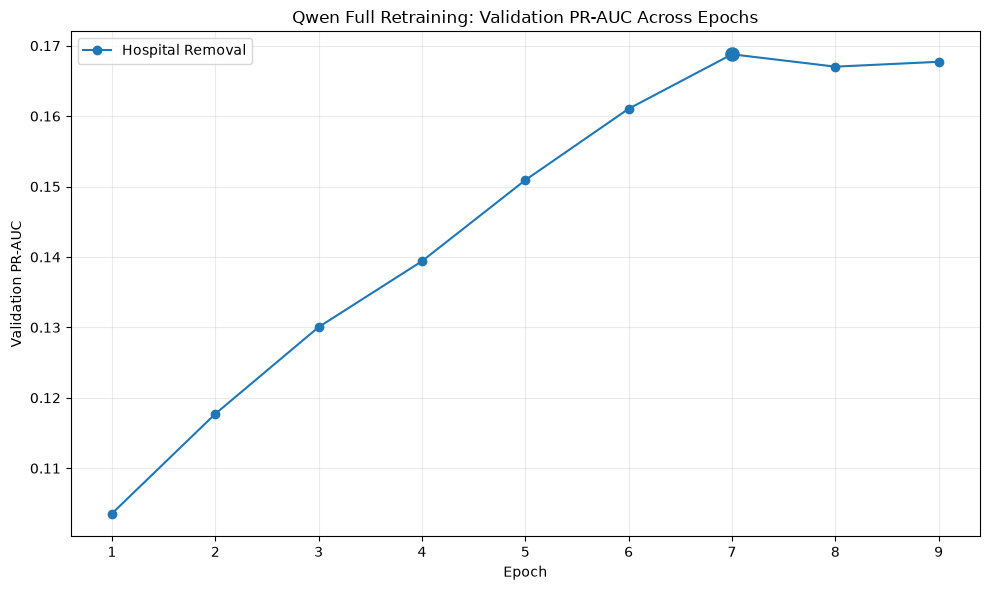

In [46]:
history_frames = []

for scenario in SCENARIOS:
    history_path = (
        RESULT_ROOT
        / scenario
        / "training_history.csv"
    )

    if history_path.is_file():
        history = pd.read_csv(history_path)
        history["Scenario"] = SCENARIO_LABELS[scenario]
        history_frames.append(history)

if not history_frames:
    print("Training histories are not available yet.")
else:
    all_history = pd.concat(
        history_frames,
        ignore_index=True,
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    for scenario_name, group in all_history.groupby("Scenario"):
        ax.plot(
            group["epoch"],
            group["validation_pr_auc"],
            marker="o",
            label=scenario_name,
        )

        best_row = group.loc[
            group["validation_pr_auc"].idxmax()
        ]

        ax.scatter(
            best_row["epoch"],
            best_row["validation_pr_auc"],
            s=90,
        )

    ax.set_title(
        "Qwen Full Retraining: Validation PR-AUC Across Epochs"
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation PR-AUC")
    ax.legend()
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(
        FIGURE_ROOT / "validation_pr_auc_training_curves.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

## 15. Figure 2 — retained-test PR-AUC by deletion scenario

This figure compares final retained-test PR-AUC across the completed Full Retraining models. The Original Qwen PR-AUC is shown as a horizontal reference line when it can be recovered from the saved baseline result files.

### 15.1 Try to recover Original Qwen PR-AUC from the saved baseline outputs

In [47]:
def find_pr_auc_in_object(obj):
    preferred_keys = [
        "test_pr_auc",
        "pr_auc",
        "PR-AUC",
        "average_precision",
    ]

    if isinstance(obj, dict):
        for key in preferred_keys:
            if key in obj and isinstance(obj[key], (int, float)):
                return float(obj[key])

        for value in obj.values():
            found = find_pr_auc_in_object(value)
            if found is not None:
                return found

    if isinstance(obj, list):
        for value in obj:
            found = find_pr_auc_in_object(value)
            if found is not None:
                return found

    return None


def load_original_qwen_pr_auc():
    # Search saved JSON outputs first.
    for path in sorted(BASELINE_RESULT_DIR.glob("*.json")):
        try:
            obj = json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            continue

        value = find_pr_auc_in_object(obj)

        if value is not None and 0 <= value <= 1:
            return value, path.name

    # Then search simple CSV outputs.
    for path in sorted(BASELINE_RESULT_DIR.glob("*.csv")):
        try:
            frame = pd.read_csv(path)
        except Exception:
            continue

        for column in [
            "test_pr_auc",
            "pr_auc",
            "PR-AUC",
            "average_precision",
        ]:
            if column in frame.columns and len(frame):
                value = float(frame.iloc[-1][column])
                if 0 <= value <= 1:
                    return value, path.name

    return None, None


ORIGINAL_QWEN_PR_AUC, ORIGINAL_QWEN_PR_AUC_SOURCE = (
    load_original_qwen_pr_auc()
)

print("Original Qwen PR-AUC:", ORIGINAL_QWEN_PR_AUC)
print("Recovered from:", ORIGINAL_QWEN_PR_AUC_SOURCE)

Original Qwen PR-AUC: 0.1761997140104368
Recovered from: test_metrics.csv


### 15.2 Plot the Full Retraining comparison

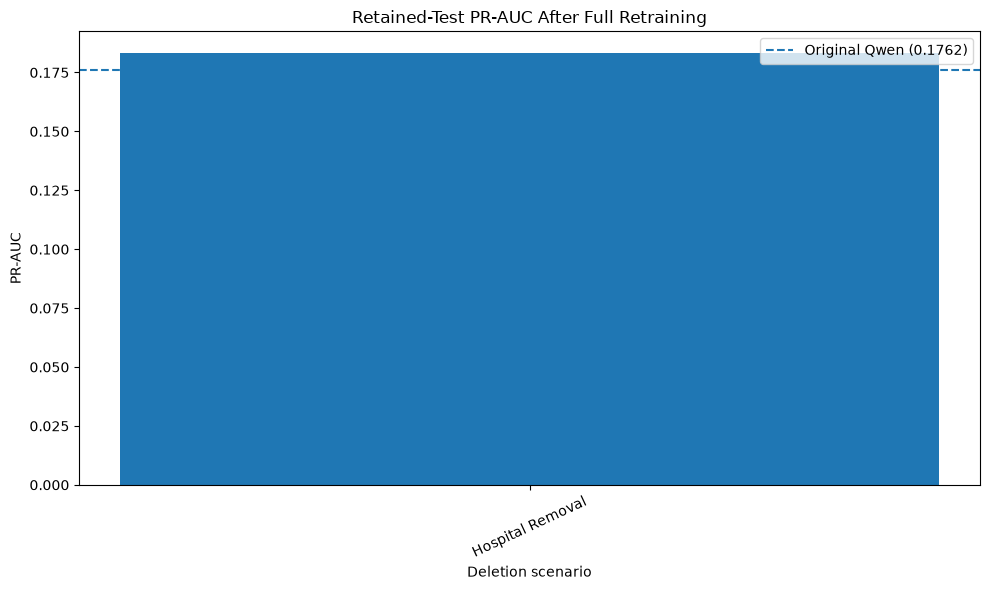

In [48]:
if completed_df.empty:
    print("No Full Retraining test results are available yet.")
else:
    plot_df = completed_df[
        ["scenario", "test_pr_auc"]
    ].copy()

    plot_df["Scenario"] = plot_df["scenario"].map(
        SCENARIO_LABELS
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(
        plot_df["Scenario"],
        plot_df["test_pr_auc"],
    )

    if ORIGINAL_QWEN_PR_AUC is not None:
        ax.axhline(
            ORIGINAL_QWEN_PR_AUC,
            linestyle="--",
            linewidth=1.5,
            label=(
                "Original Qwen "
                f"({ORIGINAL_QWEN_PR_AUC:.4f})"
            ),
        )
        ax.legend()

    ax.set_title(
        "Retained-Test PR-AUC After Full Retraining"
    )
    ax.set_xlabel("Deletion scenario")
    ax.set_ylabel("PR-AUC")
    ax.tick_params(axis="x", rotation=25)

    plt.tight_layout()
    plt.savefig(
        FIGURE_ROOT / "retained_test_pr_auc_by_scenario.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

## 16. Forget-set reference outputs

The forget-set probabilities are **reference predictions**, not an unlearning score by themselves. Later, the approximate unlearning model can be compared with the corresponding Full Retraining predictions using the chosen forgetting measures.

In [49]:
forget_summary_rows = []

for scenario in SCENARIOS:
    path = (
        RESULT_ROOT
        / scenario
        / "forget_set_probabilities.csv"
    )

    if path.is_file():
        frame = pd.read_csv(path)

        forget_summary_rows.append(
            {
                "Scenario": SCENARIO_LABELS[scenario],
                "Forget rows": len(frame),
                "Positive prevalence": frame["label"].mean(),
                "Mean predicted probability": (
                    frame["probability_class_1"].mean()
                ),
            }
        )

if forget_summary_rows:
    forget_summary = pd.DataFrame(forget_summary_rows)
    display(forget_summary.round(4))
else:
    print("Forget-set reference probabilities are not available yet.")

,Scenario,Forget rows,Positive prevalence,Mean predicted probability
0,Hospital Removal,4314,0.0751,0.2526


## 17. Runtime summary

In [50]:
if completed_df.empty:
    print("No runtime results are available yet.")
else:
    runtime_table = completed_df[
        [
            "scenario",
            "training_seconds",
            "peak_gpu_memory_gib",
        ]
    ].copy()

    runtime_table["Scenario"] = (
        runtime_table["scenario"].map(SCENARIO_LABELS)
    )

    runtime_table["Training minutes"] = (
        runtime_table["training_seconds"] / 60
    )

    runtime_table = runtime_table[
        [
            "Scenario",
            "Training minutes",
            "peak_gpu_memory_gib",
        ]
    ].rename(
        columns={
            "peak_gpu_memory_gib": "Peak GPU memory (GiB)"
        }
    )

    display(runtime_table.round(2))

,Scenario,Training minutes,Peak GPU memory (GiB)
0,Hospital Removal,487.64,10.16


## 18. Save the combined summary

In [51]:
if not completed_df.empty:
    completed_df.to_csv(
        RESULT_ROOT / "full_retraining_summary.csv",
        index=False,
    )

    print(
        "Saved:",
        RESULT_ROOT / "full_retraining_summary.csv",
    )
else:
    print("Nothing to save yet.")

Saved: /workspace/qwen35_classifier_runpod/full_retraining/20260830T134352Z/results/full_retraining_summary.csv


## 19. Final artefact verification

In [52]:
verification_rows = []

for scenario in SCENARIOS:
    result_dir = RESULT_ROOT / scenario
    model_dir = MODEL_ROOT / scenario

    artefacts = {
        "Complete marker": result_dir / "COMPLETE.json",
        "Training history": result_dir / "training_history.csv",
        "Retained-test metrics": result_dir / "retained_test_metrics.csv",
        "Retained-test probabilities": result_dir / "retained_test_probabilities.csv",
        "Forget-set probabilities": result_dir / "forget_set_probabilities.csv",
        "Adapter": model_dir / "best_adapter" / "adapter_config.json",
        "Classification head": model_dir / "binary_classification_head.pt",
    }

    for artefact, path in artefacts.items():
        verification_rows.append(
            {
                "Scenario": SCENARIO_LABELS[scenario],
                "Artefact": artefact,
                "Exists": path.exists(),
                "Path": str(path),
            }
        )

verification = pd.DataFrame(verification_rows)

display(verification)

all_complete = (
    len(verification) > 0
    and verification["Exists"].all()
)

print("ALL FIVE FULL RETRAINING REFERENCES COMPLETE:", all_complete)

,Scenario,Artefact,Exists,Path
0,Recipient Withdrawal,Complete marker,False,/workspace/qwen35_classifier_runpod/full_retra...
1,Recipient Withdrawal,Training history,False,/workspace/qwen35_classifier_runpod/full_retra...
2,Recipient Withdrawal,Retained-test metrics,False,/workspace/qwen35_classifier_runpod/full_retra...
3,Recipient Withdrawal,Retained-test probabilities,False,/workspace/qwen35_classifier_runpod/full_retra...
4,Recipient Withdrawal,Forget-set probabilities,False,/workspace/qwen35_classifier_runpod/full_retra...
5,Recipient Withdrawal,Adapter,False,/workspace/qwen35_classifier_runpod/full_retra...
6,Recipient Withdrawal,Classification head,False,/workspace/qwen35_classifier_runpod/full_retra...
7,Donor Withdrawal,Complete marker,False,/workspace/qwen35_classifier_runpod/full_retra...
8,Donor Withdrawal,Training history,False,/workspace/qwen35_classifier_runpod/full_retra...
9,Donor Withdrawal,Retained-test metrics,False,/workspace/qwen35_classifier_runpod/full_retra...


ALL FIVE FULL RETRAINING REFERENCES COMPLETE: False


### 19.1 Save a run manifest

In [53]:
manifest = {
    "run_id": RUN_ID,
    "baseline_run_id": BASELINE_RUN_ID,
    "model_id": MODEL_ID,
    "method": (
        "fresh pretrained Qwen base + fresh LoRA/classification "
        "head trained on retained training data only"
    ),
    "scenario_order": SCENARIOS,
    "expected_training_forget_counts": (
        EXPECTED_TRAINING_FORGET_COUNTS
    ),
    "frozen_threshold": FROZEN_THRESHOLD,
    "output_root": str(RUN_ROOT),
    "all_complete": bool(all_complete),
}

manifest_path = RESULT_ROOT / "run_manifest.json"

manifest_path.write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

print("Manifest saved:", manifest_path)

Manifest saved: /workspace/qwen35_classifier_runpod/full_retraining/20260830T134352Z/results/run_manifest.json


## 20. Findings to complete after the run

After all five models have completed, use the tables and figures above to record the main findings:

- whether validation PR-AUC converged consistently across the deletion scenarios;
- whether larger or more structured deletion requests changed retained-test PR-AUC;
- whether retained utility remained close to the Original Qwen baseline; and
- how Full Retraining runtime changed as the retained training-set size changed.

The saved forget-set probabilities should be carried forward unchanged to the later Gradient Difference comparison.